# Assignment 1
# Sparse Bayesian Neural Networks using Automatic Relevance Determination

Variational Dropout ([arXiv:1506.02557](https://arxiv.org/abs/1506.02557)) provides a Bayesian interpretation of the conventional dropout procedure. Later it was shown that Variational Dropout can be used for model sparsification (Sparse VD), an the effect can be achieved via optimization of variational lower bound wrt individual dropout rates for every weight of the model ([arXiv:1701.05369](https://arxiv.org/abs/1701.05369)).

In this assignment we would consider another interpretation of this model that uses the *Automatic Relevance Determination* (ARD) prior. This model is described in [arXiv:1811.00596](https://arxiv.org/abs/1811.00596).

#### ARD BNN

The ARD BNN model optimizes the evidence lower bound (ELBO) $\mathcal{L}(\phi)$ with respect to parameters $\phi$ of a variational approximation $q_\phi(w)$:

$$\mathcal{L}(\phi) =  L_\mathcal{D}(\phi) - D_{KL}(q_\phi(w)\,\|\,p(w\,|\,\lambda^2)) \to\max_{\phi, \lambda^2},$$
$$L_\mathcal{D}(\phi) = \sum_{n=1}^N \mathrm{E}_{q_\phi(w)}[\log p(y_n\,|\,x_n, w)],$$
$$p(w_{ij}\,|\,\lambda^2_{ij})=\mathcal{N}(w_{ij}\,|\,0,\lambda^2_{ij})\text{ is the ARD prior,}$$

$$q_\phi(w_{ij}) = \mathcal{N}(w_{ij}\,|\,\mu_{ij},\sigma^2_{ij})\text{ is the fully-factorized Gaussian posterior approximation},$$

and the log-likelihood $p(y\,|\,x, w)$ is defined by a neural network with parametrs $w$ using a conventional cross-entropy loss function. The optimization is performed by stochasic optimization methods. Adam with default hyperparameters and a simple multi step LR schedule should work fine.

The optimization w.r.t. the prior variance $\lambda^2$ can be performed analytically; the optimal value is $\lambda_{ij}^2=\mu_{ij}^2+\sigma_{ij}^2$. The KL-divergence term then becomes equal to:

$$D_{KL}(q_\phi(w)\,\|\,p(w\,|\,\lambda^2))=\frac12\sum_{ij}\log(1+\frac{\mu_{ij}^2}{\sigma_{ij}^2}).$$

**Note:** You will need to refer to the value $\log\alpha_{ij}=\log\frac{\sigma_{ij}^2}{\mu_{ij}^2}$ in order to determine which weights to zero out. It is also convenient to use it to compute the KL divergence. A rule of thumb is to zero out all the weights that have $\log\alpha_{ij}>3$, but you can use another threshold.

**Note:** Optimize w.r.t. $\log\sigma$ instead of $\sigma$ to better represent small values of $\sigma$.

**Note:** Some of the operations (e.g. log and square root) can be unstable for small arguments. In order to avoid NaNs, you can add a "safe" modification: just add a small constant (e.g. `1e-8`) to the argument and / or use appropriate clamping.

![alt text](https://raw.githubusercontent.com/senya-ashukha/senya-ashukha.github.io/bd8c169c6b162dac5aa77013d70463eae0927c5e/images/svd3.png)


# In this assignment:
1. Implementation of fully-connected ARD Layer
2. Training Lenet-300-100 on MNIST dataset (test accuracy should be $\geq 98.1$)
3. Optional Research Assignment

Additional information:
- If you have a problem with importing logger, download logger.py and file to the same folder and run a notebook from it
- You will need the following python packages: pytorch, numpy, sklearn, pylab (matplotlib), tabulate
- If you have an urgent question or find a typo or a mistake, text it to Alexander Grishin in Discord

In [5]:
import math
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.nn import Parameter
from torchvision import datasets, transforms

from logger import Logger

## Implementation of  the Linear ARD layer

In [6]:
class LinearARD(nn.Module):
    def __init__(self, in_features, out_features, threshold, bias=True):
        super(LinearARD, self).__init__()
        """
            in_features: int, a number of input features
            out_features: int, a number of neurons
            threshold: float, a threshold for clipping weights
        """
        
        self.in_features = in_features
        self.out_features = out_features
        self.threshold = threshold

        self.mu = Parameter(torch.Tensor(out_features, in_features))
        self.log_sigma = Parameter(torch.Tensor(out_features, in_features))
        self.bias = Parameter(torch.Tensor(1, out_features))
        self.reset_parameters()
        
    def reset_parameters(self):
        self.bias.data.zero_()
        self.mu.data.normal_(0, 0.02)
        self.log_sigma.data.fill_(-5)        
        
    def forward(self, x):      
        # x is a torch.Tensor of shape (number_of_objects, in_features)
        # log_alpha is a torch.Tensor of shape (out_features, in_features)
        self.log_alpha = 2 * self.log_sigma - torch.log(self.mu ** 2 + 1e-8)
        self.log_alpha = torch.clamp(self.log_alpha, -10, 10)   
        
        if self.training:
            lrt_mean = F.linear(x, self.mu) + self.bias
            lrt_std = torch.sqrt(F.linear(x ** 2, torch.exp(2 * self.log_sigma)) + 1e-8)
            eps = torch.randn_like(lrt_mean)
            return lrt_mean + lrt_std * eps
        
        mask = (self.log_alpha < self.threshold).float()
        out = F.linear(x, self.mu * mask) + self.bias
        return out
        
    def kl_reg(self):
        # kl is a scalar torch.Tensor 
        kl = 0.5 * torch.sum(torch.log1p(torch.exp(-self.log_alpha)))
        return kl

## Define LeNet-300-100

In [7]:
class Net(nn.Module):
    def __init__(self, threshold):
        super(Net, self).__init__()
        self.fc1 = LinearARD(28*28, 300, threshold)
        self.fc2 = LinearARD(300,  100, threshold)
        self.fc3 = LinearARD(100,  10, threshold)
        self.threshold=threshold

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.log_softmax(self.fc3(x), dim=1)
        return x

## Function for loading MNIST

In [8]:
def get_mnist(batch_size):
    trsnform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_loader = torch.utils.data.DataLoader(
        datasets.MNIST('../data', train=True, download=True,
        transform=trsnform), batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(
        datasets.MNIST('../data', train=False, download=True,
        transform=trsnform), batch_size=batch_size, shuffle=True)

    return train_loader, test_loader

## Define the ELBO loss function

In [9]:
class ELBO(nn.Module):
    def __init__(self, net, train_size):
        super(ELBO, self).__init__()
        self.train_size = train_size # int, the len of dataset
        self.net = net # nn.Module
        
    def forward(self, input, target, kl_weight=1.0):
        """
          input: is a torch.Tensor (a predictions of the model) 
          target: is a torch.Tensor (a tensor of labels) 
        """
        assert not target.requires_grad
        kl = 0.0
        for module in self.net.children():
            if hasattr(module, 'kl_reg'):
                kl = kl + module.kl_reg()
                
        elbo_loss = F.nll_loss(input, target) + kl_weight * kl / self.train_size
        return elbo_loss

## Define the model

In [10]:
model = Net(threshold=3)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 75], gamma=0.1)

logger = Logger('ard', fmt={
    'tr_loss': '3.1e',
    'te_loss': '3.1e',
    'sp_0':    '.3f',
    'sp_1':    '.3f',
    'sp_2':    '.3f',
    'lr':      '3.1e',
    'kl':      '.2f',
    'time':    '.2f',
})

train_loader, test_loader = get_mnist(batch_size=100)
elbo = ELBO(model, len(train_loader.dataset))

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.92MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 295kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.98MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


## Train the model

In [11]:
# Switch the device to cuda to reduce one epoch from ~30 sec to ~10 sec

device = 'cpu'
# device = 'cuda:0'

model = model.to(device)
elbo = elbo.to(device)

kl_weight = 0.02
epochs = 100

for epoch in range(1, epochs + 1):
    time_start = time.perf_counter()
    scheduler.step()
    model.train()
    train_loss, train_acc = 0, 0 
    kl_weight = min(kl_weight+0.02, 1)
    logger.add_scalar(epoch, 'kl', kl_weight)
    logger.add_scalar(epoch, 'lr', scheduler.get_lr()[0])
    for batch_idx, (data, target) in enumerate(train_loader):
        data = data.to(device)
        target = target.to(device)
        
        data = data.view(-1, 28*28)
        optimizer.zero_grad()
        
        output = model(data)
        pred = output.data.max(1)[1] 
        loss = elbo(output, target, kl_weight)
        loss.backward()
        optimizer.step()
        
        train_loss += float(loss) 
        train_acc += np.sum(pred.cpu().numpy() == target.data.cpu().numpy())

    logger.add_scalar(epoch, 'tr_loss', train_loss / len(train_loader.dataset))
    logger.add_scalar(epoch, 'tr_acc', train_acc / len(train_loader.dataset) * 100)
    
    model.eval()
    test_loss, test_acc = 0, 0
    for batch_idx, (data, target) in enumerate(test_loader):
        data = data.to(device)
        target = target.to(device)
        
        data = data.view(-1, 28*28)
        output = model(data)
        test_loss += float(elbo(output, target, kl_weight))
        pred = output.data.max(1)[1] 
        test_acc += np.sum(pred.cpu().numpy() == target.data.cpu().numpy())
        
    logger.add_scalar(epoch, 'te_loss', test_loss / len(test_loader.dataset))
    logger.add_scalar(epoch, 'te_acc', test_acc / len(test_loader.dataset) * 100)
    
    for i, c in enumerate(model.children()):
        if hasattr(c, 'kl_reg'):
            logger.add_scalar(epoch, 'sp_%s' % i, (c.log_alpha.data.cpu().numpy() > model.threshold).mean())
    
    logger.add_scalar(epoch, 'time', time.perf_counter() - time_start)
    logger.iter_info()

/Users/danila.biktimirov/Library/Python/3.12/lib/python/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/Users/danila.biktimirov/Library/Python/3.12/lib/python/site-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_79278/2190261541.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /

      step |         kl |         lr |    tr_loss |     tr_acc |    te_loss |     te_acc |       sp_0 |       sp_1 |       sp_2 |       time
         1 |       0.04 |    1.0e-03 |    4.2e-03 |    90.6833 |    2.3e-03 |    95.6100 |      0.353 |      0.131 |      0.039 |       8.54
         2 |       0.06 |    1.0e-03 |    2.2e-03 |    96.3883 |    1.8e-03 |    96.8100 |      0.458 |      0.214 |      0.064 |       8.39
         3 |       0.08 |    1.0e-03 |    1.8e-03 |    97.2717 |    1.7e-03 |    97.3400 |      0.525 |      0.288 |      0.062 |       8.36
         4 |       0.10 |    1.0e-03 |    1.6e-03 |    97.7483 |    1.6e-03 |    97.5200 |      0.597 |      0.352 |      0.075 |       8.25
         5 |       0.12 |    1.0e-03 |    1.5e-03 |    98.0050 |    1.4e-03 |    97.8400 |      0.663 |      0.402 |      0.080 |       8.28
         6 |       0.14 |    1.0e-03 |    1.4e-03 |    98.2183 |    1.4e-03 |    97.9500 |      0.734 |      0.469 |      0.098 |       8.28
         7 | 

In [12]:
all_w, kep_w = 0, 0

for c in model.children():
    kep_w += (c.log_alpha.data.cpu().numpy() < model.threshold).sum()
    all_w += c.log_alpha.data.cpu().numpy().size

# compression_ratio should be > 25
compression_ratio = all_w/kep_w
print('compression_ratio =', compression_ratio)
assert compression_ratio >= 25

compression_ratio = 30.9642898685588


## Disk space

In [13]:
import scipy
import numpy as np
from scipy.sparse import csc_matrix, csc_matrix, coo_matrix, dok_matrix

row, col, data = [], [], []
M = list(model.children())[0].mu.data.cpu().numpy()
LA = list(model.children())[0].log_alpha.data.cpu().numpy()

for i in range(300):
    for j in range(28*28):
        if LA[i, j] < 3:
            row += [i]
            col += [j]
            data += [M[i, j]]

Mcsr = csc_matrix((data, (row, col)), shape=(300, 28*28))
Mcsc = csc_matrix((data, (row, col)), shape=(300, 28*28))
Mcoo = coo_matrix((data, (row, col)), shape=(300, 28*28))

In [14]:
np.savez_compressed('M_w', M)
scipy.sparse.save_npz('Mcsr_w', Mcsr)
scipy.sparse.save_npz('Mcsc_w', Mcsc)
scipy.sparse.save_npz('Mcoo_w', Mcoo)

In [15]:
!ls -lah | grep .npz 

-rw-r--r--   1 danila.biktimirov  staff   818K Mar 12 11:50 M_w.npz
-rw-r--r--   1 danila.biktimirov  staff    34K Mar 12 11:50 Mcoo_w.npz
-rw-r--r--   1 danila.biktimirov  staff    33K Mar 12 11:50 Mcsc_w.npz
-rw-r--r--   1 danila.biktimirov  staff    33K Mar 12 11:50 Mcsr_w.npz


## Visualization

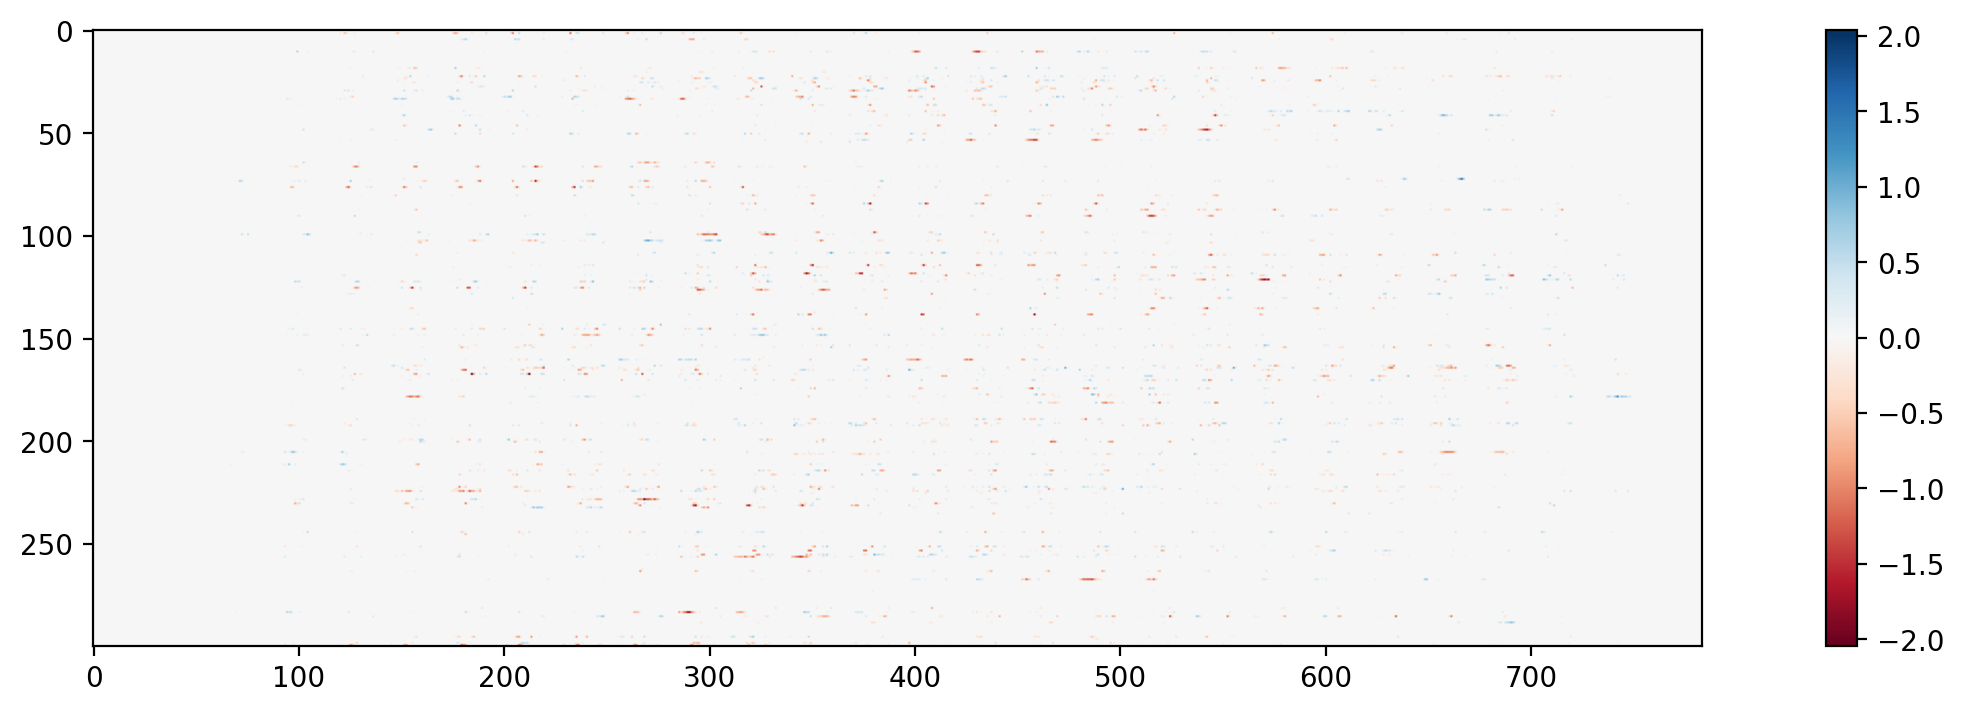

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl

from matplotlib import rcParams
rcParams['figure.figsize'] = 16, 4
rcParams['figure.dpi'] = 200


mask = (model.fc1.log_alpha.detach().cpu().numpy() < 3).astype(float)
W = model.fc1.mu.detach().cpu().numpy()

# Normalize color map
max_val = np.max(np.abs(mask * W))
norm = mpl.colors.Normalize(vmin=-max_val,vmax=max_val)

plt.imshow(mask * W, cmap='RdBu', interpolation=None, norm=norm)
plt.colorbar()

(np.float64(-0.5), np.float64(419.5), np.float64(419.5), np.float64(-0.5))

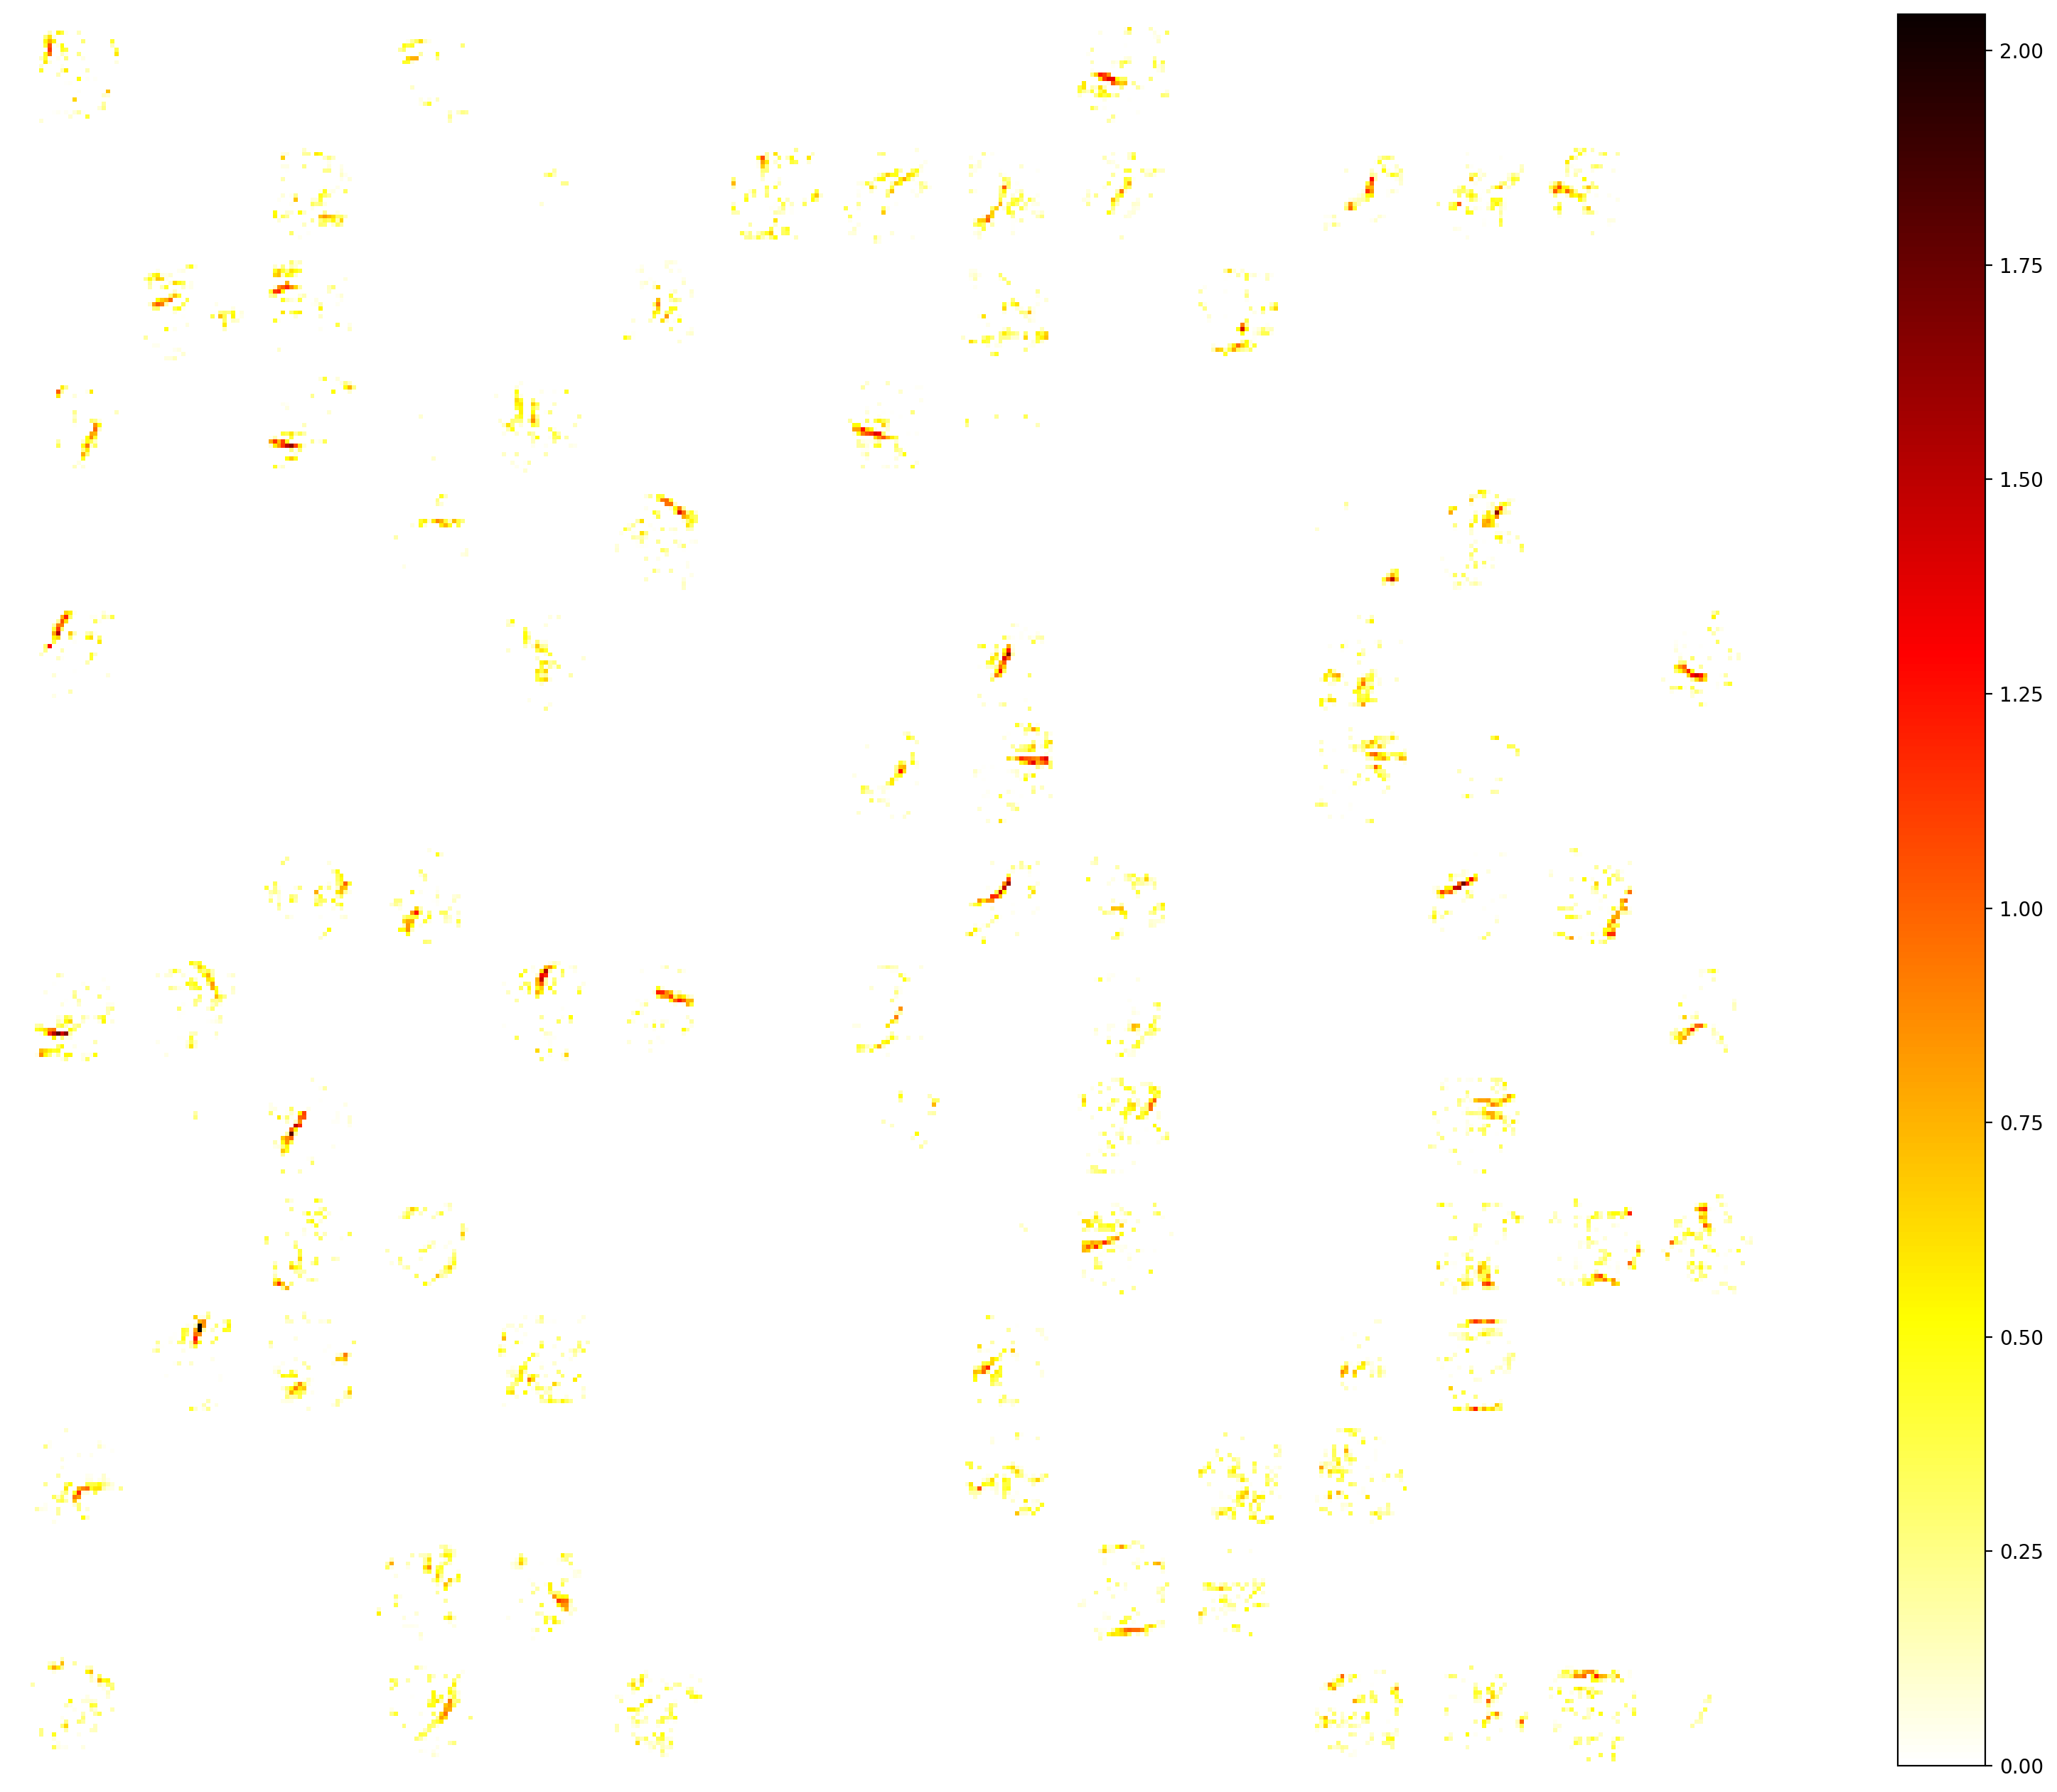

In [18]:
s = 0
z = np.zeros((28*15, 28*15))

for i in range(15):
    for j in range(15):
        s += 1
        z[i*28:(i+1)*28, j*28:(j+1)*28] = np.abs((mask * W)[s].reshape(28, 28))

plt.figure(figsize=(24, 16))
plt.imshow(z, cmap='hot_r')
plt.colorbar()
plt.axis('off')

# Optional Research Assignment (up to 2 additional points)

1. Study the model: 
    - How sparsity and accuracy depend on maximum of KL-multiplier (kl_weight)?
    - How sparsity and accuracy depend on the initialization?
    - Study the KL: what if we optimize w.r.t. $\lambda^2$ using Adam instead of substituting the optimal $\lambda^2$?
    - How does the behaviour of optimization change if you use another parameterization for the approximate posterior? How does it affect the variance of the stochastic gradients?
2. Compression:
    - What can we do to obtain better compression results with small quality degradation?
    - Propose and eval several options.
3. Study the Local reparametrization trick: 
    - Does it really accelerate convergence?
    - Does variance of gradient decrease?
    
You can do one out of three parts. You need to provide evidence for results e.g., plots, etc.

## Part 1: Study the model

We investigate how **sparsity** and **accuracy** of the ARD BNN depend on:
1. The maximum value of the KL-multiplier (`max_kl_weight`)
2. The initialization of model parameters ($\mu$ std and $\log\sigma$ init)

In [19]:
def train_ard_model(max_kl_weight=1.0, epochs=50, lr=1e-3,
                    mu_std=0.02, log_sigma_init=-5, threshold=3,
                    device='cpu', verbose=True):
    """Train an ARD BNN and return metrics history."""
    model = Net(threshold=threshold)
    for m in model.children():
        if isinstance(m, LinearARD):
            m.mu.data.normal_(0, mu_std)
            m.log_sigma.data.fill_(log_sigma_init)
            m.bias.data.zero_()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[epochs // 2, 3 * epochs // 4], gamma=0.1)
    train_loader, test_loader = get_mnist(batch_size=100)
    elbo_fn = ELBO(model, len(train_loader.dataset))
    model, elbo_fn = model.to(device), elbo_fn.to(device)

    history = {'train_acc': [], 'test_acc': [], 'sparsity': [], 'sp_per_layer': []}
    kl_weight = 0.0
    kl_step = 2.0 * max_kl_weight / epochs

    for epoch in range(1, epochs + 1):
        scheduler.step()
        model.train()
        train_acc = 0
        kl_weight = min(kl_weight + kl_step, max_kl_weight)

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            data = data.view(-1, 28 * 28)
            optimizer.zero_grad()
            output = model(data)
            loss = elbo_fn(output, target, kl_weight)
            loss.backward()
            optimizer.step()
            train_acc += (output.data.max(1)[1].cpu() == target.cpu()).sum().item()

        model.eval()
        test_acc = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                data = data.view(-1, 28 * 28)
                output = model(data)
                test_acc += (output.data.max(1)[1].cpu() == target.cpu()).sum().item()

        n_train, n_test = len(train_loader.dataset), len(test_loader.dataset)
        all_w, pruned_w, sp_layers = 0, 0, []
        for c in model.children():
            if hasattr(c, 'log_alpha'):
                la = c.log_alpha.data.cpu().numpy()
                sp_layers.append(float((la > threshold).mean()))
                pruned_w += int((la > threshold).sum())
                all_w += la.size

        history['train_acc'].append(train_acc / n_train * 100)
        history['test_acc'].append(test_acc / n_test * 100)
        history['sparsity'].append(pruned_w / all_w)
        history['sp_per_layer'].append(sp_layers)

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f"  Epoch {epoch:3d}/{epochs} | Test Acc: {test_acc / n_test * 100:.2f}% | "
                  f"Sparsity: {pruned_w / all_w:.3f} | KL wt: {kl_weight:.3f}")

    return history, model

### 1.1 How do sparsity and accuracy depend on the maximum KL-multiplier?

We train models with different caps on `kl_weight`: $\{0.1,\; 0.3,\; 0.5,\; 1.0,\; 2.0\}$. A higher maximum forces the KL term to dominate, pushing the posterior towards the prior and pruning more weights.

In [20]:
device = 'cpu'
# device = 'cuda:0'

max_kl_weights = [0.1, 0.3, 0.5, 1.0, 2.0]
results_kl = {}

for mkw in max_kl_weights:
    print(f"\n{'=' * 55}")
    print(f"  max_kl_weight = {mkw}")
    print(f"{'=' * 55}")
    hist, _ = train_ard_model(max_kl_weight=mkw, epochs=50, device=device)
    results_kl[mkw] = hist
    print(f"  >>> Final: Acc = {hist['test_acc'][-1]:.2f}%, Sparsity = {hist['sparsity'][-1]:.3f}")


  max_kl_weight = 0.1


/Users/danila.biktimirov/Library/Python/3.12/lib/python/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  Epoch   1/50 | Test Acc: 95.76% | Sparsity: 0.084 | KL wt: 0.004
  Epoch  10/50 | Test Acc: 98.06% | Sparsity: 0.466 | KL wt: 0.040
  Epoch  20/50 | Test Acc: 98.49% | Sparsity: 0.645 | KL wt: 0.080
  Epoch  30/50 | Test Acc: 98.60% | Sparsity: 0.794 | KL wt: 0.100
  Epoch  40/50 | Test Acc: 98.63% | Sparsity: 0.834 | KL wt: 0.100
  Epoch  50/50 | Test Acc: 98.62% | Sparsity: 0.841 | KL wt: 0.100
  >>> Final: Acc = 98.62%, Sparsity = 0.841

  max_kl_weight = 0.3
  Epoch   1/50 | Test Acc: 96.14% | Sparsity: 0.156 | KL wt: 0.012
  Epoch  10/50 | Test Acc: 98.25% | Sparsity: 0.673 | KL wt: 0.120
  Epoch  20/50 | Test Acc: 98.35% | Sparsity: 0.792 | KL wt: 0.240
  Epoch  30/50 | Test Acc: 98.37% | Sparsity: 0.896 | KL wt: 0.300
  Epoch  40/50 | Test Acc: 98.43% | Sparsity: 0.911 | KL wt: 0.300
  Epoch  50/50 | Test Acc: 98.43% | Sparsity: 0.913 | KL wt: 0.300
  >>> Final: Acc = 98.43%, Sparsity = 0.913

  max_kl_weight = 0.5
  Epoch   1/50 | Test Acc: 95.96% | Sparsity: 0.218 | KL wt: 0

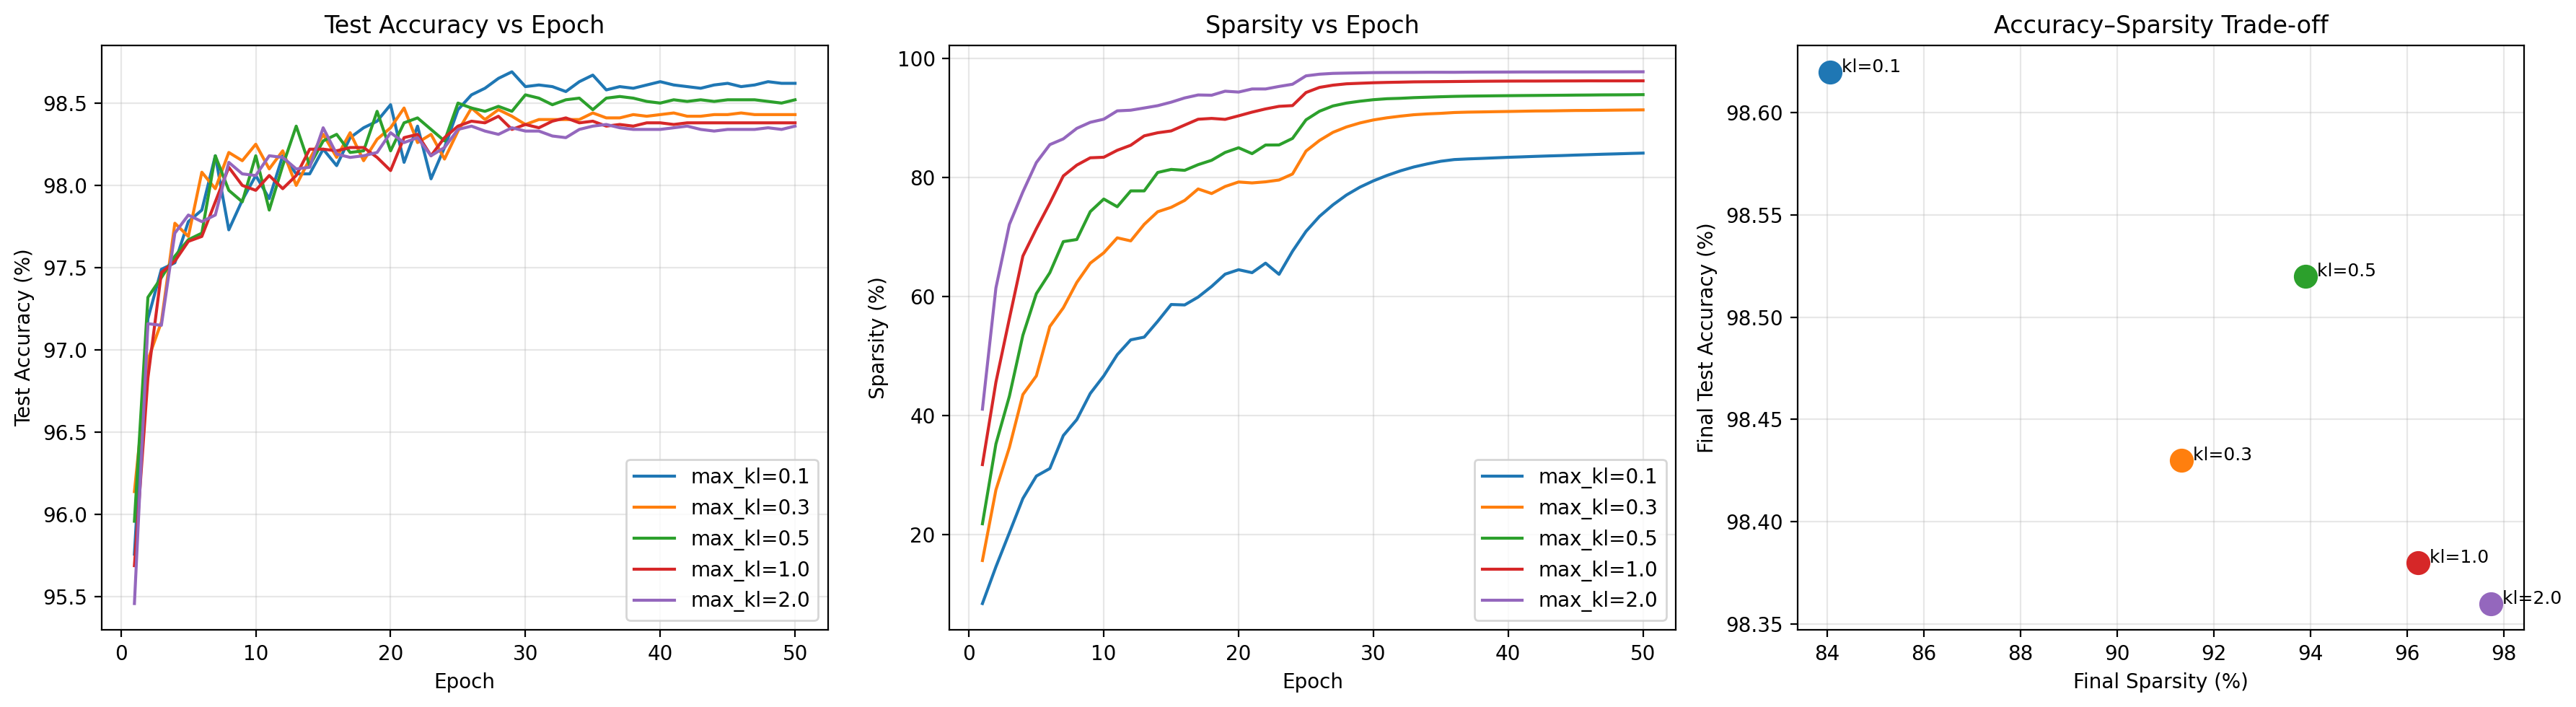

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for mkw, hist in results_kl.items():
    ep = range(1, len(hist['test_acc']) + 1)
    axes[0].plot(ep, hist['test_acc'], label=f'max_kl={mkw}')
    axes[1].plot(ep, [s * 100 for s in hist['sparsity']], label=f'max_kl={mkw}')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy vs Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Sparsity (%)')
axes[1].set_title('Sparsity vs Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

for mkw, hist in results_kl.items():
    axes[2].scatter(hist['sparsity'][-1] * 100, hist['test_acc'][-1], s=120, zorder=5)
    axes[2].annotate(f'  kl={mkw}', (hist['sparsity'][-1] * 100, hist['test_acc'][-1]), fontsize=9)
axes[2].set_xlabel('Final Sparsity (%)'); axes[2].set_ylabel('Final Test Accuracy (%)')
axes[2].set_title('Accuracy–Sparsity Trade-off'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 How do sparsity and accuracy depend on the initialization?

We vary **log σ init** $\in \{-3,\, -5,\, -7,\, -10\}$ (controls initial posterior variance) and **μ std** $\in \{0.005,\, 0.02,\, 0.1\}$ (controls initial weight scale), keeping all other hyperparameters at their defaults.

Together they determine the initial signal-to-noise ratio $\log\alpha = 2\log\sigma - \log\mu^2$, which controls the initial pruning landscape.

In [22]:
log_sigma_inits = [-3, -5, -7, -10]
results_sigma = {}

for lsi in log_sigma_inits:
    print(f"\n{'=' * 55}")
    print(f"  log_sigma_init = {lsi}")
    print(f"{'=' * 55}")
    hist, _ = train_ard_model(log_sigma_init=lsi, epochs=50, device=device)
    results_sigma[lsi] = hist
    print(f"  >>> Final: Acc = {hist['test_acc'][-1]:.2f}%, Sparsity = {hist['sparsity'][-1]:.3f}")

mu_stds = [0.005, 0.02, 0.1]
results_mu = {}

for ms in mu_stds:
    print(f"\n{'=' * 55}")
    print(f"  mu_std = {ms}")
    print(f"{'=' * 55}")
    hist, _ = train_ard_model(mu_std=ms, epochs=50, device=device)
    results_mu[ms] = hist
    print(f"  >>> Final: Acc = {hist['test_acc'][-1]:.2f}%, Sparsity = {hist['sparsity'][-1]:.3f}")


  log_sigma_init = -3
  Epoch   1/50 | Test Acc: 95.95% | Sparsity: 0.339 | KL wt: 0.040
  Epoch  10/50 | Test Acc: 98.25% | Sparsity: 0.772 | KL wt: 0.400
  Epoch  20/50 | Test Acc: 98.34% | Sparsity: 0.883 | KL wt: 0.800
  Epoch  30/50 | Test Acc: 98.39% | Sparsity: 0.938 | KL wt: 1.000
  Epoch  40/50 | Test Acc: 98.39% | Sparsity: 0.943 | KL wt: 1.000
  Epoch  50/50 | Test Acc: 98.40% | Sparsity: 0.943 | KL wt: 1.000
  >>> Final: Acc = 98.40%, Sparsity = 0.943

  log_sigma_init = -5
  Epoch   1/50 | Test Acc: 96.01% | Sparsity: 0.336 | KL wt: 0.040
  Epoch  10/50 | Test Acc: 98.25% | Sparsity: 0.824 | KL wt: 0.400
  Epoch  20/50 | Test Acc: 98.32% | Sparsity: 0.897 | KL wt: 0.800
  Epoch  30/50 | Test Acc: 98.58% | Sparsity: 0.958 | KL wt: 1.000
  Epoch  40/50 | Test Acc: 98.55% | Sparsity: 0.961 | KL wt: 1.000
  Epoch  50/50 | Test Acc: 98.57% | Sparsity: 0.961 | KL wt: 1.000
  >>> Final: Acc = 98.57%, Sparsity = 0.961

  log_sigma_init = -7
  Epoch   1/50 | Test Acc: 95.85% | Spa

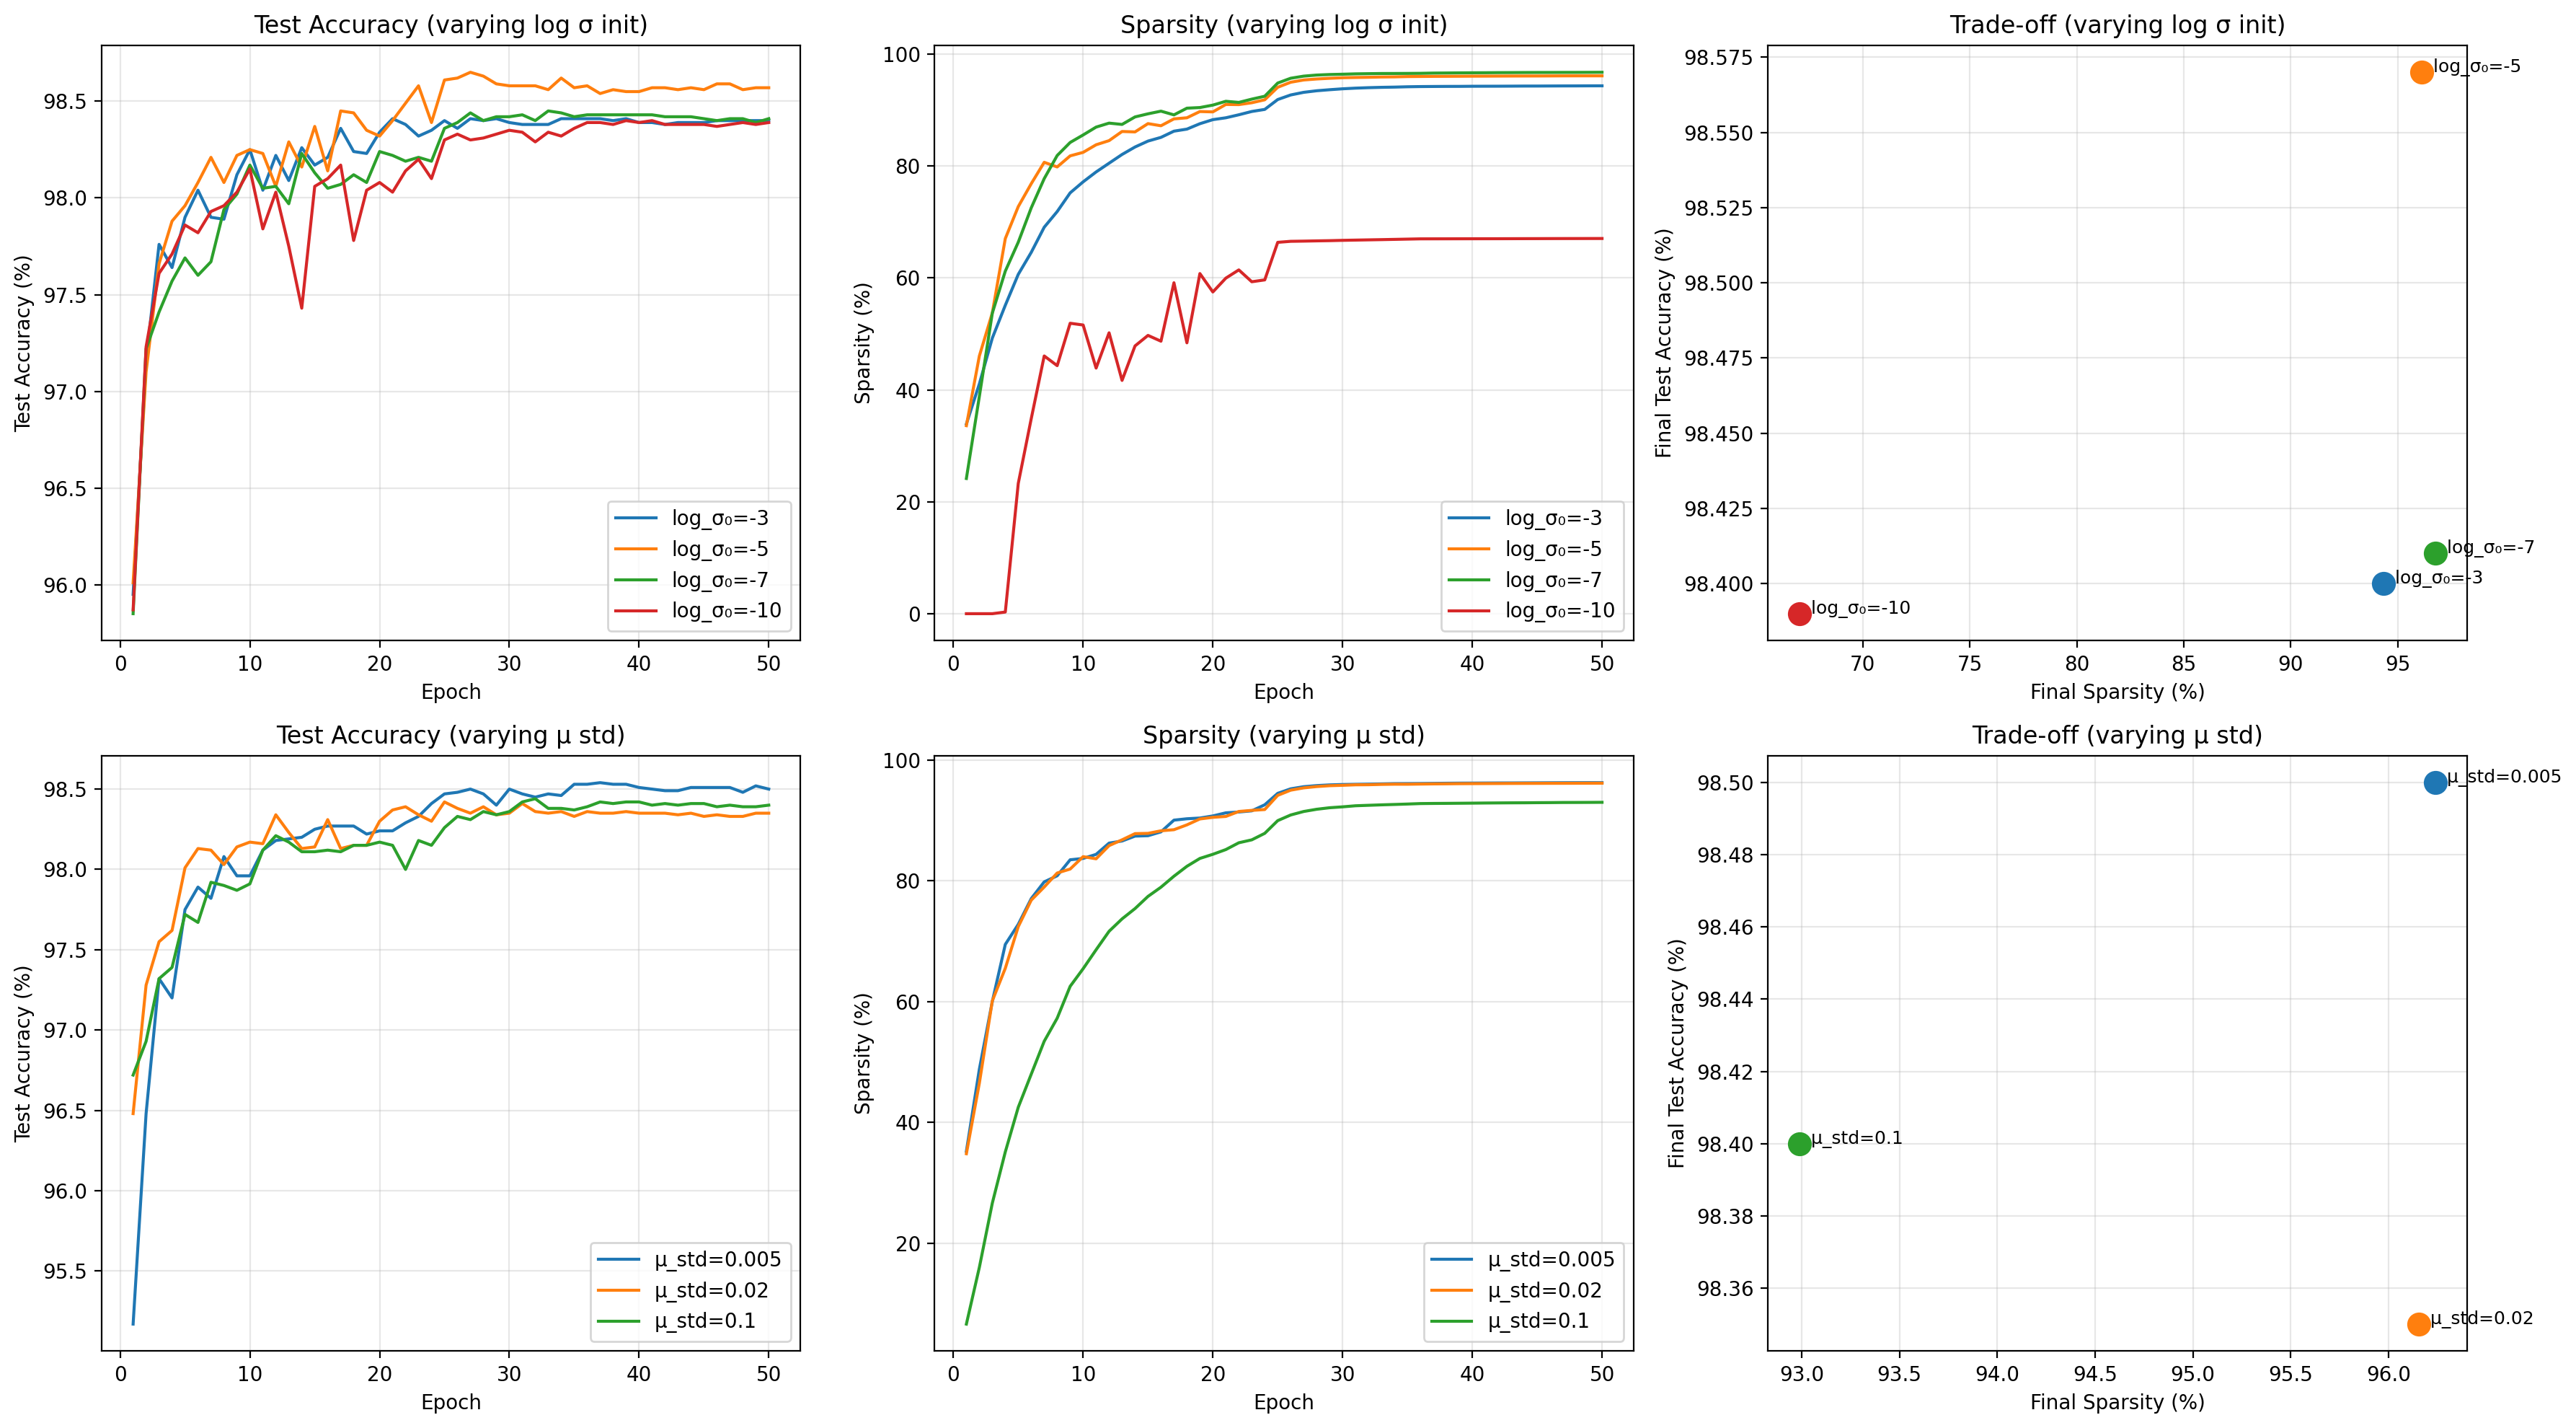

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for lsi, hist in results_sigma.items():
    ep = range(1, len(hist['test_acc']) + 1)
    axes[0, 0].plot(ep, hist['test_acc'], label=f'log_σ₀={lsi}')
    axes[0, 1].plot(ep, [s * 100 for s in hist['sparsity']], label=f'log_σ₀={lsi}')

axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Test Accuracy (%)')
axes[0, 0].set_title('Test Accuracy (varying log σ init)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Sparsity (%)')
axes[0, 1].set_title('Sparsity (varying log σ init)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

for lsi, hist in results_sigma.items():
    axes[0, 2].scatter(hist['sparsity'][-1] * 100, hist['test_acc'][-1], s=120, zorder=5)
    axes[0, 2].annotate(f'  log_σ₀={lsi}',
                        (hist['sparsity'][-1] * 100, hist['test_acc'][-1]), fontsize=9)
axes[0, 2].set_xlabel('Final Sparsity (%)'); axes[0, 2].set_ylabel('Final Test Accuracy (%)')
axes[0, 2].set_title('Trade-off (varying log σ init)'); axes[0, 2].grid(True, alpha=0.3)

for ms, hist in results_mu.items():
    ep = range(1, len(hist['test_acc']) + 1)
    axes[1, 0].plot(ep, hist['test_acc'], label=f'μ_std={ms}')
    axes[1, 1].plot(ep, [s * 100 for s in hist['sparsity']], label=f'μ_std={ms}')

axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Test Accuracy (%)')
axes[1, 0].set_title('Test Accuracy (varying μ std)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Sparsity (%)')
axes[1, 1].set_title('Sparsity (varying μ std)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

for ms, hist in results_mu.items():
    axes[1, 2].scatter(hist['sparsity'][-1] * 100, hist['test_acc'][-1], s=120, zorder=5)
    axes[1, 2].annotate(f'  μ_std={ms}',
                        (hist['sparsity'][-1] * 100, hist['test_acc'][-1]), fontsize=9)
axes[1, 2].set_xlabel('Final Sparsity (%)'); axes[1, 2].set_ylabel('Final Test Accuracy (%)')
axes[1, 2].set_title('Trade-off (varying μ std)'); axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()